In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
movies = pd.read_csv('/content/drive/My Drive/Colab Notebooks/movies.csv')
ratings = pd.read_csv('/content/drive/My Drive/Colab Notebooks/ratings.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [16]:
from scipy.sparse import csr_matrix
import pandas as pd

# Map movieId and userId to continuous indices
ratings['movie_index'] = ratings['movieId'].astype('category').cat.codes
ratings['user_index'] = ratings['userId'].astype('category').cat.codes

# Create sparse matrix (movies × users)
final_dataset = csr_matrix((ratings['rating'], (ratings['movie_index'], ratings['user_index'])))

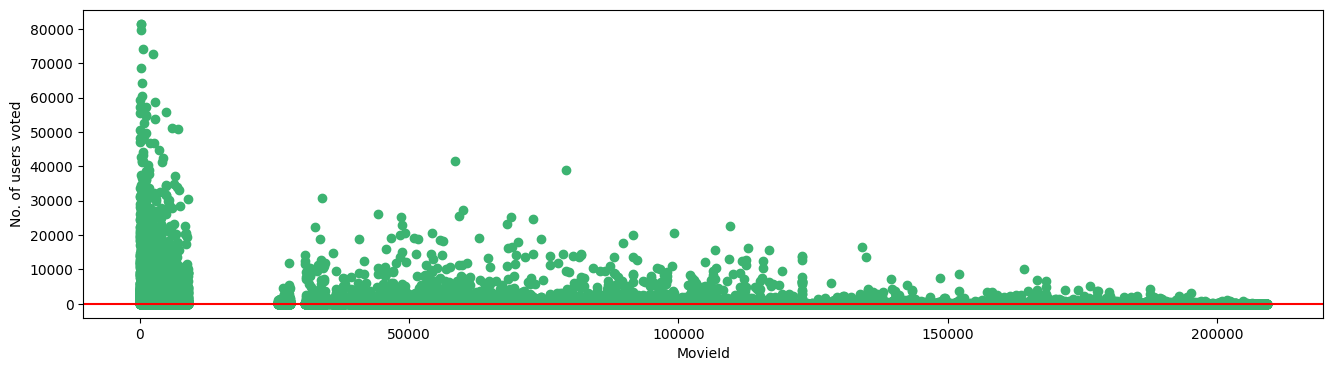

In [17]:
no_user_voted = ratings.groupby('movieId')['rating'].agg('count')
no_movies_voted = ratings.groupby('userId')['rating'].agg('count')

f,ax = plt.subplots(1,1,figsize=(16,4))
# ratings['rating'].plot(kind='hist')
plt.scatter(no_user_voted.index,no_user_voted,color='mediumseagreen')
plt.axhline(y=10,color='r')
plt.xlabel('MovieId')
plt.ylabel('No. of users voted')
plt.show()

In [18]:
sample = np.array([[0,0,3,0,0],[4,0,0,0,2],[0,0,0,0,1]])
sparsity = 1.0 - ( np.count_nonzero(sample) / float(sample.size) )
print(sparsity)

0.7333333333333334


In [19]:
csr_sample = csr_matrix(sample)
print(csr_sample)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (3, 5)>
  Coords	Values
  (0, 2)	3
  (1, 0)	4
  (1, 4)	2
  (2, 4)	1


In [23]:
# Lookup dictionaries
movieId_to_index = dict(zip(ratings['movieId'], ratings['movie_index']))
index_to_movieId = dict(zip(ratings['movie_index'], ratings['movieId']))

In [24]:
def get_movie_recommendation(movie_name, n_movies_to_reccomend=10):
    # find movies that match
    movie_list = movies[movies['title'].str.contains(movie_name, case=False, regex=False)]
    if len(movie_list) == 0:
        return "No movies found. Please check your input"

    # get the first matching movieId
    movie_id = movie_list.iloc[0]['movieId']

    # get the row index of this movie in final_dataset
    if movie_id not in movieId_to_index:
        return "Movie not found in dataset."
    movie_idx = movieId_to_index[movie_id]

    # find nearest neighbors
    knn = NearestNeighbors(metric='cosine', algorithm='brute')
    knn.fit(final_dataset)
    distances, indices = knn.kneighbors(final_dataset[movie_idx], n_neighbors=n_movies_to_reccomend+1)

    # prepare recommendations (skip the first one, since it's the same movie)
    recommend_frame = []
    for i, (idx, dist) in enumerate(zip(indices.squeeze().tolist(), distances.squeeze().tolist())):
        if idx == movie_idx:  # skip the movie itself
            continue
        rec_movie_id = index_to_movieId[idx]
        title = movies[movies['movieId'] == rec_movie_id]['title'].values[0]
        recommend_frame.append({'Title': title, 'Distance': dist})

    df = pd.DataFrame(recommend_frame, index=range(1, len(recommend_frame)+1))
    return df


In [30]:
get_movie_recommendation('Iron Man')

,Title,Distance
1,"Dark Knight, The (2008)",0.361411
2,"Avengers, The (2012)",0.380319
3,Batman Begins (2005),0.396635
4,Iron Man 2 (2010),0.399477
5,Star Trek (2009),0.410628
6,Avatar (2009),0.419392
7,WALL·E (2008),0.425247
8,Inception (2010),0.446502
9,Guardians of the Galaxy (2014),0.450216
10,Sherlock Holmes (2009),0.455910
